# BI Final Project Data Cleaning / Preprocessing

In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)

In [119]:
import kagglehub
path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
Path to dataset files: /kaggle/input/ibm-hr-analytics-attrition-dataset


In [120]:
cd /kaggle/input/ibm-hr-analytics-attrition-dataset

/kaggle/input/ibm-hr-analytics-attrition-dataset


In [121]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

## Preprocessing

In [122]:
# 1. target handling

df['target'] = df['Attrition'].apply(lambda x : 1 if x == "Yes" else 0 )
df = df.drop(columns=['Attrition'])

In [124]:
# Numerical columns (int64)
num_cols = [
    'Age', 'DailyRate', 'DistanceFromHome', 'Education',
    'EmployeeCount', 'EnvironmentSatisfaction', 'HourlyRate',
    'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate',
    'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating',
    'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
    'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
    'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
    'YearsWithCurrManager',
]

# Non-numerical columns (object/categorical)
cat_cols = [
    'BusinessTravel', 'Department', 'EducationField', 'Gender',
    'JobRole', 'MaritalStatus', 'Over18', 'OverTime'
]

In [125]:
# 2. Check for missing values
df.isnull().sum().sum()

np.int64(0)

Overall, dataset seems clean with no null values.

### Feature Selection
Here, we employ some variance thresholding to determine features which do not have significant information regarding our target due to low variance.

In [126]:
# 3.1 - Drop ID column, no information here

df = df.drop(columns=['EmployeeNumber'])

In [127]:
THRESHOLD = 0.05 # this is just an arbitrary selected value

In [128]:
# 3. Drop constant/low-variance columns using VarianceThreshold
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=THRESHOLD) 
vt.fit(df[num_cols])

dropped_num = [c for c, s in zip(num_cols, vt.get_support()) if not s]
dropped_cat = [c for c in cat_cols if df[c].nunique() <= 1]

drop_cols = dropped_num + dropped_cat
df = df.drop(columns=drop_cols)

num_cols = [c for c in num_cols if c not in drop_cols]
cat_cols = [c for c in cat_cols if c not in drop_cols]

print(f"Dropped (zero-variance numerical): {dropped_num}")
print(f"Dropped (constant categorical):    {dropped_cat}")
print(f"\nRemaining columns: {len(df.columns)}")
print(f"Numerical: {len(num_cols)}, Categorical: {len(cat_cols)}")

Dropped (zero-variance numerical): ['EmployeeCount', 'StandardHours']
Dropped (constant categorical):    ['Over18']

Remaining columns: 31
Numerical: 23, Categorical: 7


In [129]:
# 4. Encode categorical variables (one-hot encoding)

df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

print(f"Shape after encoding: {df.shape}")

Shape after encoding: (1470, 45)


### Micro EDA

<Axes: xlabel='target'>

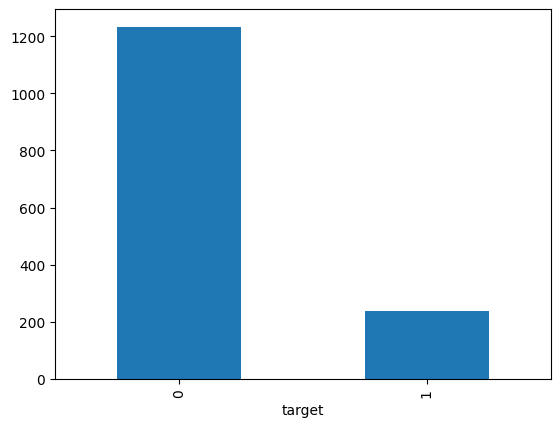

In [133]:
# 5.1 - target exploration

df['target'].value_counts().plot(kind='bar')

We seem to have some class imbalance. We will need to use other metrics (such as F1 score), and also perhaps conduct some oversampling of the minority or undersampling of the majority (SMOTE).

<Axes: >

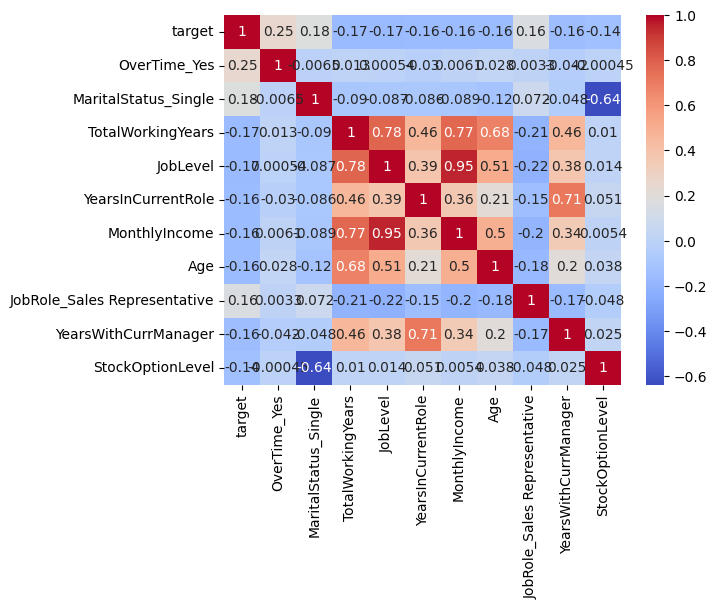

In [139]:
top_cols = df.corr()['target'].abs().nlargest(11).index
sns.heatmap(df[top_cols].corr(), annot=True, cmap='coolwarm')

Off the bat, overtime seems to be the most correlated variable with target.

### Train Test Split

In [142]:
y = df.pop('target')
X = df

In [166]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

### Normalization

In [146]:
X.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Male,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,2,94,3,2,4,5993,19479,8,11,3,1,0,8,0,1,6,4,0,5,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1
1,49,279,8,1,3,61,2,2,2,5130,24907,1,23,4,4,1,10,3,3,10,7,1,7,1,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0
2,37,1373,2,2,4,92,2,1,3,2090,2396,6,15,3,2,0,7,3,3,0,0,0,0,0,1,1,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,1,1
3,33,1392,3,4,4,56,3,1,3,2909,23159,1,11,3,3,0,8,3,3,8,7,3,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1
4,27,591,2,1,1,40,3,1,2,3468,16632,9,12,3,4,1,6,3,3,2,2,2,2,0,1,1,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,0


In [ ]:
# train normalization

scaler = StandardScaler()

norm_cols = X.columns[X.nunique() > 2]
bin_cols = X.columns[X.nunique() <= 2]

X_train_norm = pd.DataFrame(scaler.fit_transform(X_train[norm_cols]), columns=norm_cols, index=X_train.index)
X_train = pd.concat([X_train_norm, X_train[bin_cols]], axis=1) 

In [170]:
# test normalization

X_test_norm = pd.DataFrame(scaler.transform(X_test[norm_cols]), columns=norm_cols, index=X_test.index)
X_test = pd.concat([X_test_norm, X_test[bin_cols]], axis=1)

In [174]:
# ensure dtypes 

X_train = X_train.astype('float32')
X_test = X_train.astype('float32')

y_train = y_train.astype('long')
y_test = y_train.astype('long')
